# Rackow et al. (2024) Fig. 1 — global-mean 2 m temperature spaghetti plot

A continuous **ERA5 daily-mean** reference (thick black, drawn behind) with one thin **10-day rollout** line for **every start date** (drawn in front). Each autoregressive rollout's 6-hourly steps are collapsed to a **per-day mean**, so one rollout = ~11 daily points (lead day 0..10) and the diurnal wiggle is removed. Each rollout is its own line — not joined across inits.

Data source: `results_daily/daily_rollout_{year}.csv` (365 daily inits, 41 steps each = 0–240 h at 6 h).
Columns used: `init_date`, `lead_hours`, `t2m_pred_gmean_k` (NeuralGCM global-mean 2 m T), `t2m_truth_gmean_k` (ERA5 global-mean 2 m T).

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

RESULTS = Path('results_daily')
FIGDIR = Path('figures'); FIGDIR.mkdir(exist_ok=True)

def load(year):
    df = pd.read_csv(RESULTS / f'daily_rollout_{year}.csv')
    df['init_date'] = pd.to_datetime(df['init_date'])
    df['valid_time'] = df['init_date'] + pd.to_timedelta(df['lead_hours'], unit='h')
    return df

data = {y: load(y) for y in (1955, 2023)}
data[2023].head()

,year,init_date,step,lead_hours,lead_day,mse,t2m_pred_gmean_k,t2m_truth_gmean_k,t2m_rmse_k,t2m_mean_bias_k,valid_time
0,2023,2023-01-01,0,0.0,0.00,0.300050,287.080383,287.109830,0.547769,-0.018272,2023-01-01 00:00:00
1,2023,2023-01-01,1,6.0,0.25,0.253121,287.049591,287.026095,0.503111,0.022731,2023-01-01 06:00:00
2,2023,2023-01-01,2,12.0,0.50,0.358550,287.377869,287.372278,0.598791,0.001888,2023-01-01 12:00:00
3,2023,2023-01-01,3,18.0,0.75,0.365403,287.322327,287.299746,0.604486,0.021245,2023-01-01 18:00:00
4,2023,2023-01-01,4,24.0,1.00,0.460534,287.087524,287.105151,0.678627,-0.019696,2023-01-02 00:00:00


In [7]:
def spaghetti(ax, df, year, line_color='#1f77b4', every=1):
    """Continuous ERA5 daily mean + one separate 10-day rollout line every Nth day.

    Each 6-hourly autoregressive step is collapsed to a per-day mean, so one
    rollout = ~11 daily points (lead day 0..10) and the diurnal wiggle is removed.
    """
    # lead day index 0..10 from lead hours (0-18h -> day0, 24-42h -> day1, ...)
    df = df.copy()
    df['lead_day_idx'] = (df['lead_hours'] // 24).astype(int)

    # ERA5 reference: continuous daily-mean truth over the whole period.
    era5 = df[['valid_time', 't2m_truth_gmean_k']].drop_duplicates('valid_time')
    era5['date'] = era5['valid_time'].dt.floor('D')
    era5d = era5.groupby('date', as_index=False)['t2m_truth_gmean_k'].mean()
    ax.plot(era5d['date'], era5d['t2m_truth_gmean_k'],
            color='black', lw=2.2, zorder=1, label='ERA5 (daily mean)')

    # one separate continuous line per selected start date, daily means lead 0..10.
    # rollouts drawn ON TOP of ERA5 (zorder 2) so the reference no longer hides them.
    # thinner/more transparent when every==1 since ~365 lines overlap heavily.
    lw, alpha = (0.5, 0.5) if every == 1 else (0.9, 0.8)
    init_dates = sorted(df['init_date'].unique())[::every]
    for d in init_dates:
        g = df[df['init_date'] == d]
        daily = (g.groupby('lead_day_idx')
                   .agg(vt=('valid_time', 'mean'), t2m=('t2m_pred_gmean_k', 'mean'))
                   .reset_index())
        ax.plot(daily['vt'], daily['t2m'],
                color=line_color, lw=lw, alpha=alpha, zorder=2)
    # proxy handle for the thin rollout lines
    cadence = 'every day' if every == 1 else f'every {every}th day'
    ax.plot([], [], color=line_color, lw=1.2, alpha=0.9,
            label=f'NeuralGCM 10-day rollout, daily mean ({cadence})')

    ax.set_title(f'Global-mean 2 m temperature — {year}')
    ax.set_ylabel('T2m global mean [K]')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.margins(x=0.01)
    ax.grid(alpha=0.25)
    ax.legend(loc='upper left', framealpha=0.9)

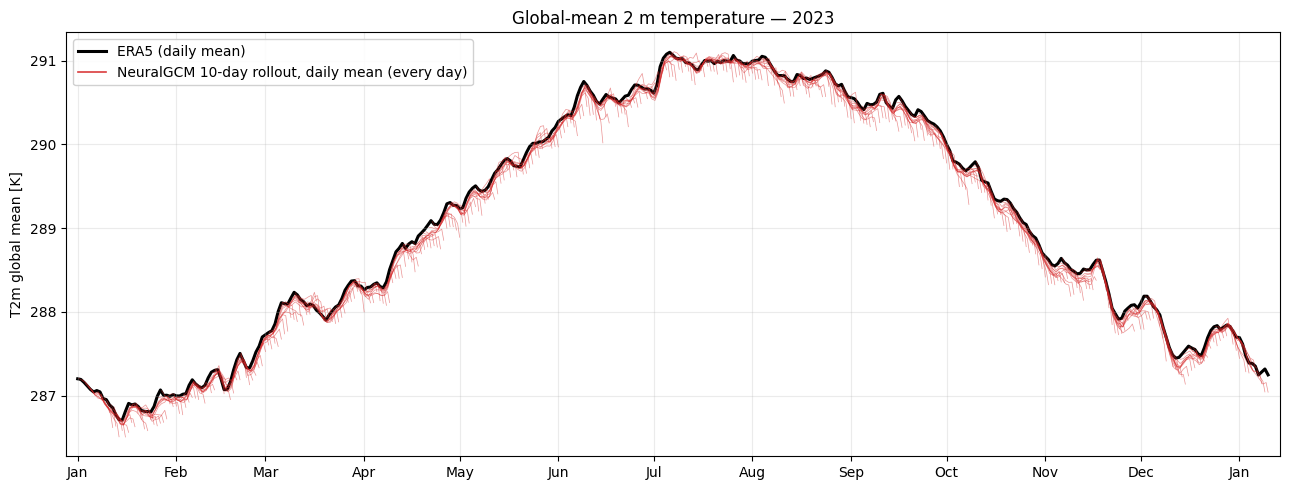

In [8]:
fig, ax = plt.subplots(figsize=(13, 5))
spaghetti(ax, data[2023], 2023, line_color='#d62728', every=1)
fig.tight_layout()
fig.savefig(FIGDIR / 'spaghetti_t2m_2023_daily.png', dpi=150, bbox_inches='tight')
plt.show()

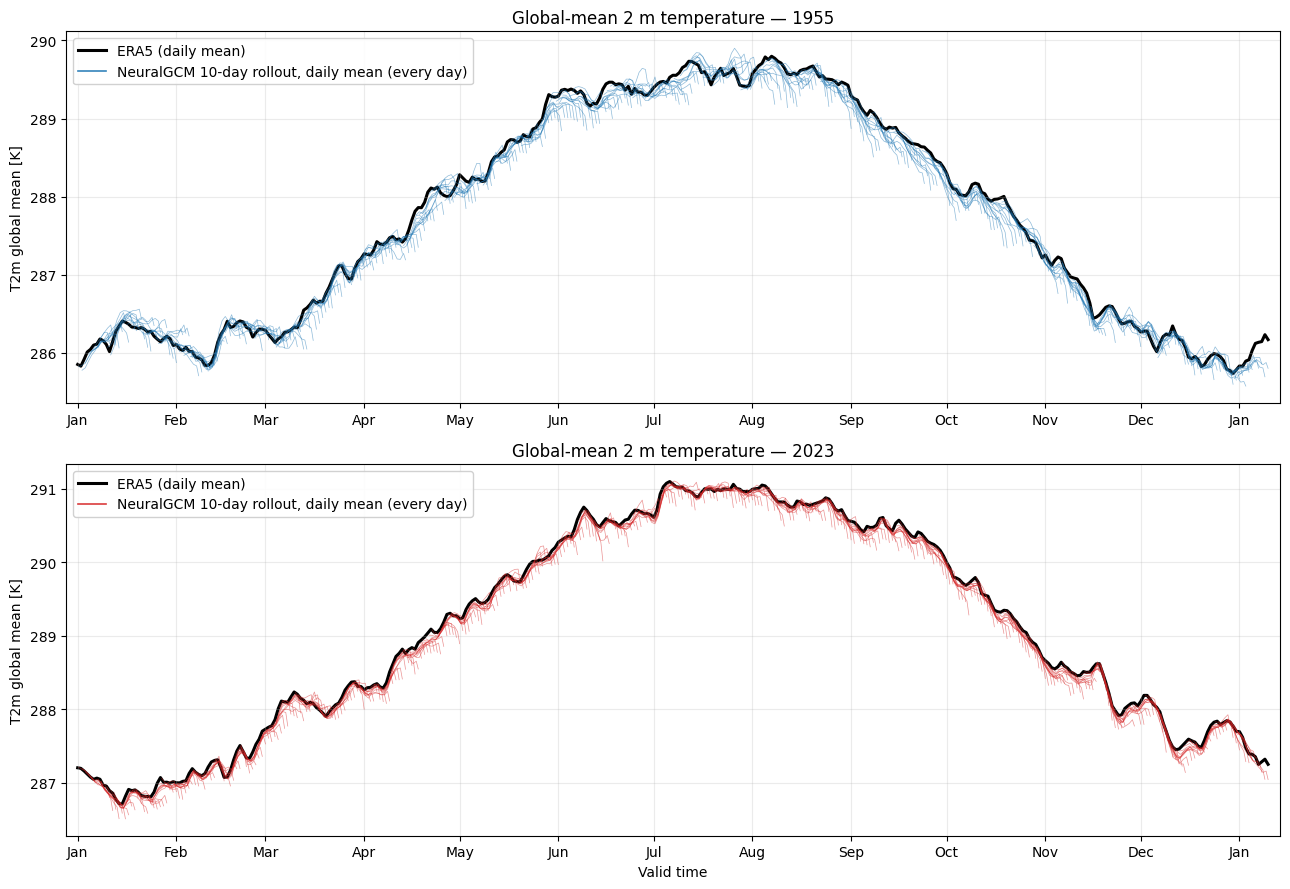

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=False)
spaghetti(axes[0], data[1955], 1955, line_color='#1f77b4', every=1)
spaghetti(axes[1], data[2023], 2023, line_color='#d62728', every=1)
axes[1].set_xlabel('Valid time')
fig.tight_layout()
fig.savefig(FIGDIR / 'spaghetti_t2m_1955_2023_daily.png', dpi=150, bbox_inches='tight')
plt.show()

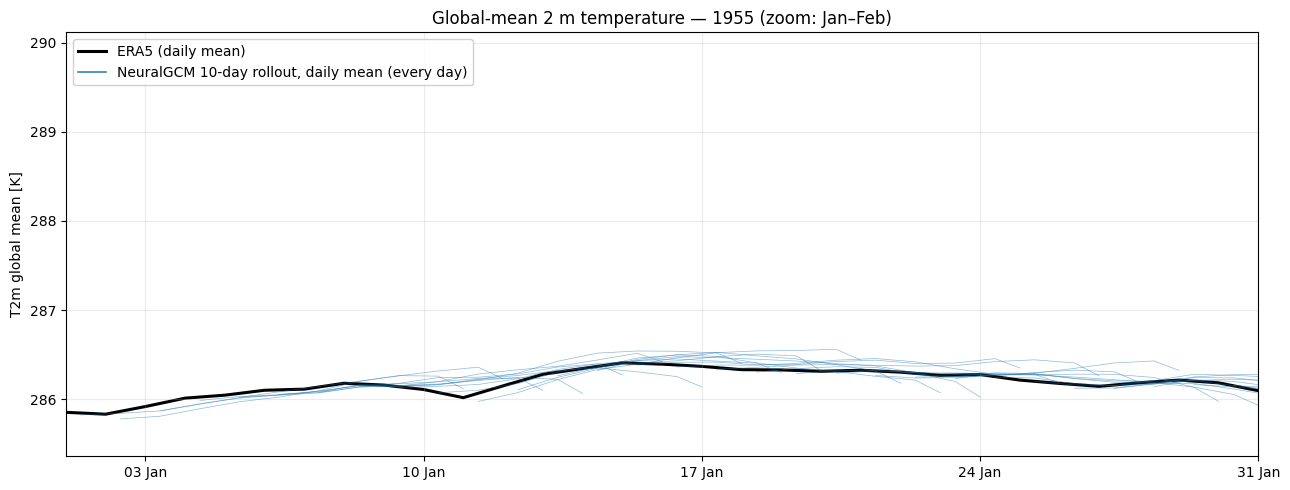

In [11]:
# Zoom: a few weeks so each 10-day rollout is visibly one separate line.
# Now every day starts a rollout (10 days long), so ~10 lines overlap at any time.
import datetime as dt
zoom = (dt.datetime(1955, 1, 1), dt.datetime(1955, 1, 31))
fig, ax = plt.subplots(figsize=(13, 5))
spaghetti(ax, data[1955], 1955, line_color='#1f77b4', every=1)
ax.set_xlim(*zoom)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.set_title('Global-mean 2 m temperature — 1955 (zoom: Jan–Feb)')
fig.tight_layout()
fig.savefig(FIGDIR / 'spaghetti_t2m_1955_daily_zoom.png', dpi=150, bbox_inches='tight')
plt.show()